# Exploratory Data Exploration - Titanic Dataset
Checking out some of the interesting facts about the dataset

Implementation is as Follows:
1. Load the Titanic Dataset
2. Do various Visualization and Try to get some insight from data

In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading and Data Exploration

In [224]:
data = pd.read_csv("data/titanic.csv")
print("Data shape (rows, cols):", data.shape)
print("Columns in the dataset:", data.columns.tolist())
data.head()

Data shape (rows, cols): (887, 8)
Columns in the dataset: ['sex', 'age', 'family_size', 'fare', '1st_class', '2nd_class', '3rd_class', 'survived']


,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


In [225]:
data.tail(5)

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
882,1,27.0,0,13.00,0,1,0,0
883,0,19.0,0,30.00,1,0,0,1
884,0,7.0,3,23.45,0,0,1,0
885,1,26.0,0,30.00,1,0,0,1
886,1,32.0,0,7.75,0,0,1,0


### 1.1 Data Types and Non-Null count info and Some statistical info about the dataset

- There is no missing value in the dataset, every value is non-null
- All columns have numeric dataset (floats and integers)
- There are total 8 columns and 887 rows in the dataset

In [226]:
data.isna().sum()

sex            0
age            0
family_size    0
fare           0
1st_class      0
2nd_class      0
3rd_class      0
survived       0
dtype: int64

In [227]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB


- Max family size is 10
- Max Fare was 512.32
- Oldest person on Titanic was 80 year old

In [228]:
data.describe()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
count,887.000000,887.000000,887.000000,887.00000,887.000000,887.000000,887.000000,887.000000
mean,0.645998,29.471443,0.908681,32.30542,0.243517,0.207441,0.549042,0.385569
std,0.478480,14.121908,1.615949,49.78204,0.429447,0.405703,0.497870,0.487004
min,0.000000,0.420000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.250000,0.000000,7.92500,0.000000,0.000000,0.000000,0.000000
50%,1.000000,28.000000,0.000000,14.45420,0.000000,0.000000,1.000000,0.000000
75%,1.000000,38.000000,1.000000,31.13750,0.000000,0.000000,1.000000,1.000000
max,1.000000,80.000000,10.000000,512.32920,1.000000,1.000000,1.000000,1.000000


- There were 573 Males and 314 Females on the Ship
- 64.5% Males and 35.5% Females

In [229]:
data.sex.value_counts()

sex
1    573
0    314
Name: count, dtype: int64

In [230]:
data.sex.value_counts()/len(data)

sex
1    0.645998
0    0.354002
Name: count, dtype: float64

#### Percent of Passengers travelling in different class
- 1st class: 0.24%

- 2nd class: 0.21%

- 3rd class: 0.55%

In [231]:
p1 = data['1st_class'].value_counts()
p2 = data['2nd_class'].value_counts()
p3 = data['3rd_class'].value_counts()

percentage_p1 = p1[1]/len(data)
percentage_p2 = p2[1]/len(data)
percentage_p3 = p3[1]/len(data)

print(f"passengers travelling in 1st class: {round(percentage_p1, 2)}%")
print(f"\npassengers travelling in 2nd class: {round(percentage_p2, 2)}%")
print(f"\npassengers travelling in 3rd class: {round(percentage_p3, 2)}%")

passengers travelling in 1st class: 0.24%

passengers travelling in 2nd class: 0.21%

passengers travelling in 3rd class: 0.55%


### 1.2 Visualization about the data and Exploration of relation between surviver and other factors

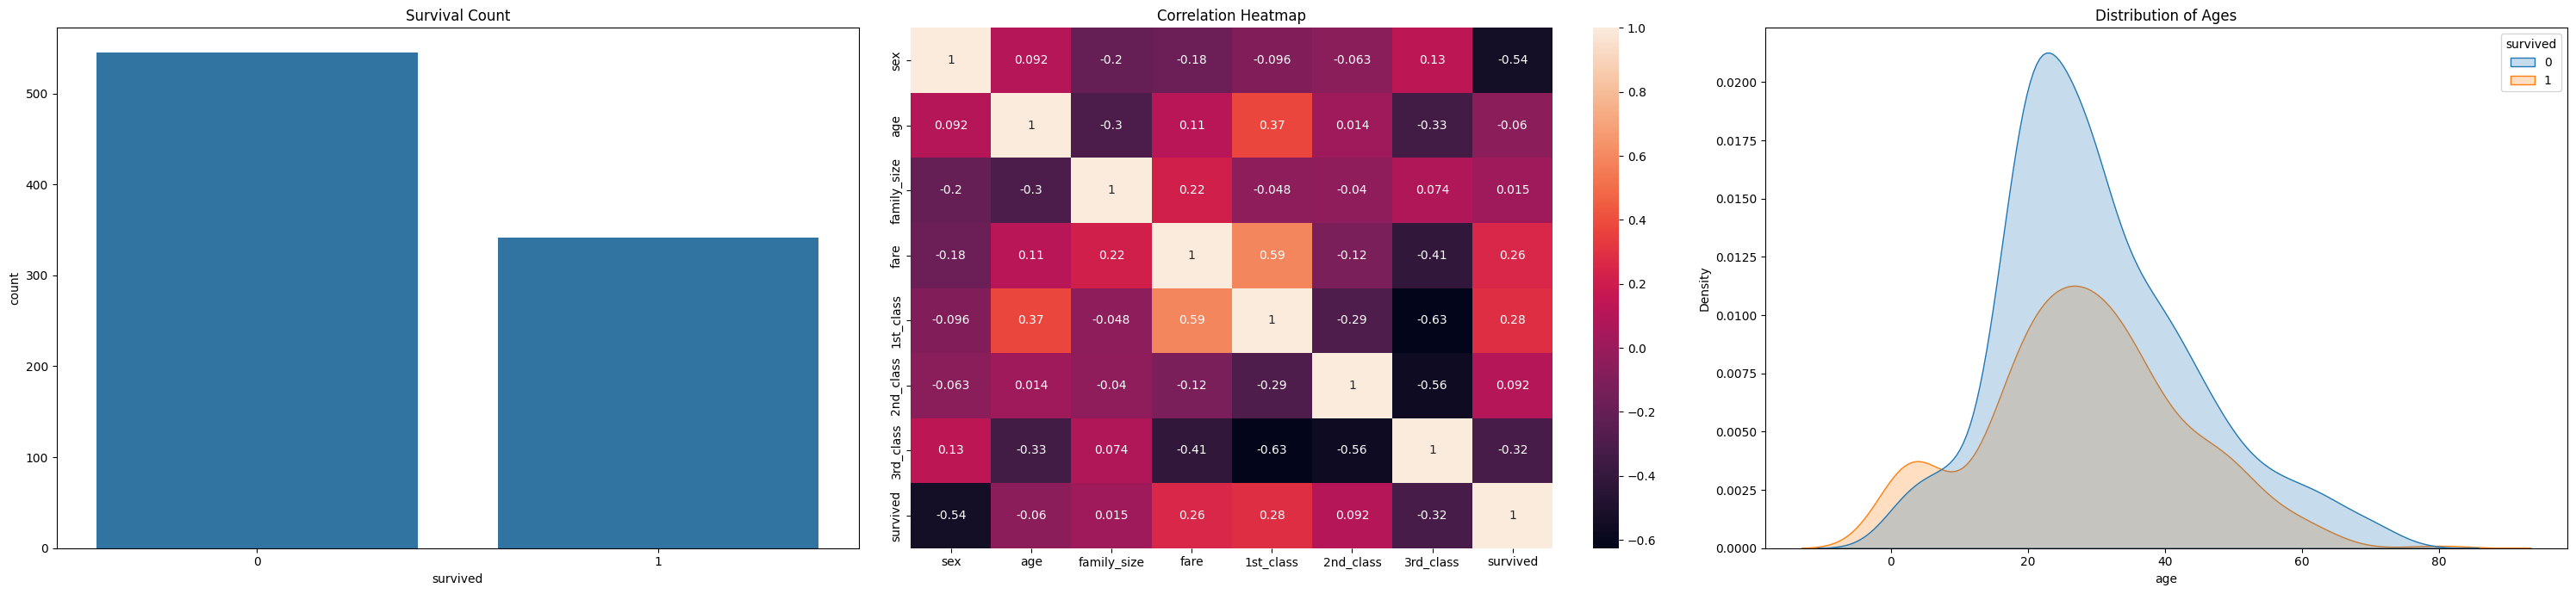

In [232]:
fig, axes = plt.subplots(1, 3, figsize=(30, 7))

# Number of survivors vs non-survivors
# We can clearly see that it is Binomial Logistic regression problem
sns.countplot(x="survived", data=data, ax=axes[0])
axes[0].set_title("Survival Count")

# Correlation heatmap of numerical features
sns.heatmap(data.corr(), annot=True, ax=axes[1])
axes[1].set_title("Correlation Heatmap")

# Distribution of ages
sns.kdeplot(x="age", data=data, fill=True, ax=axes[2], hue="survived", common_norm=True)
axes[2].set_title("Distribution of Ages")

plt.tight_layout()
plt.show()

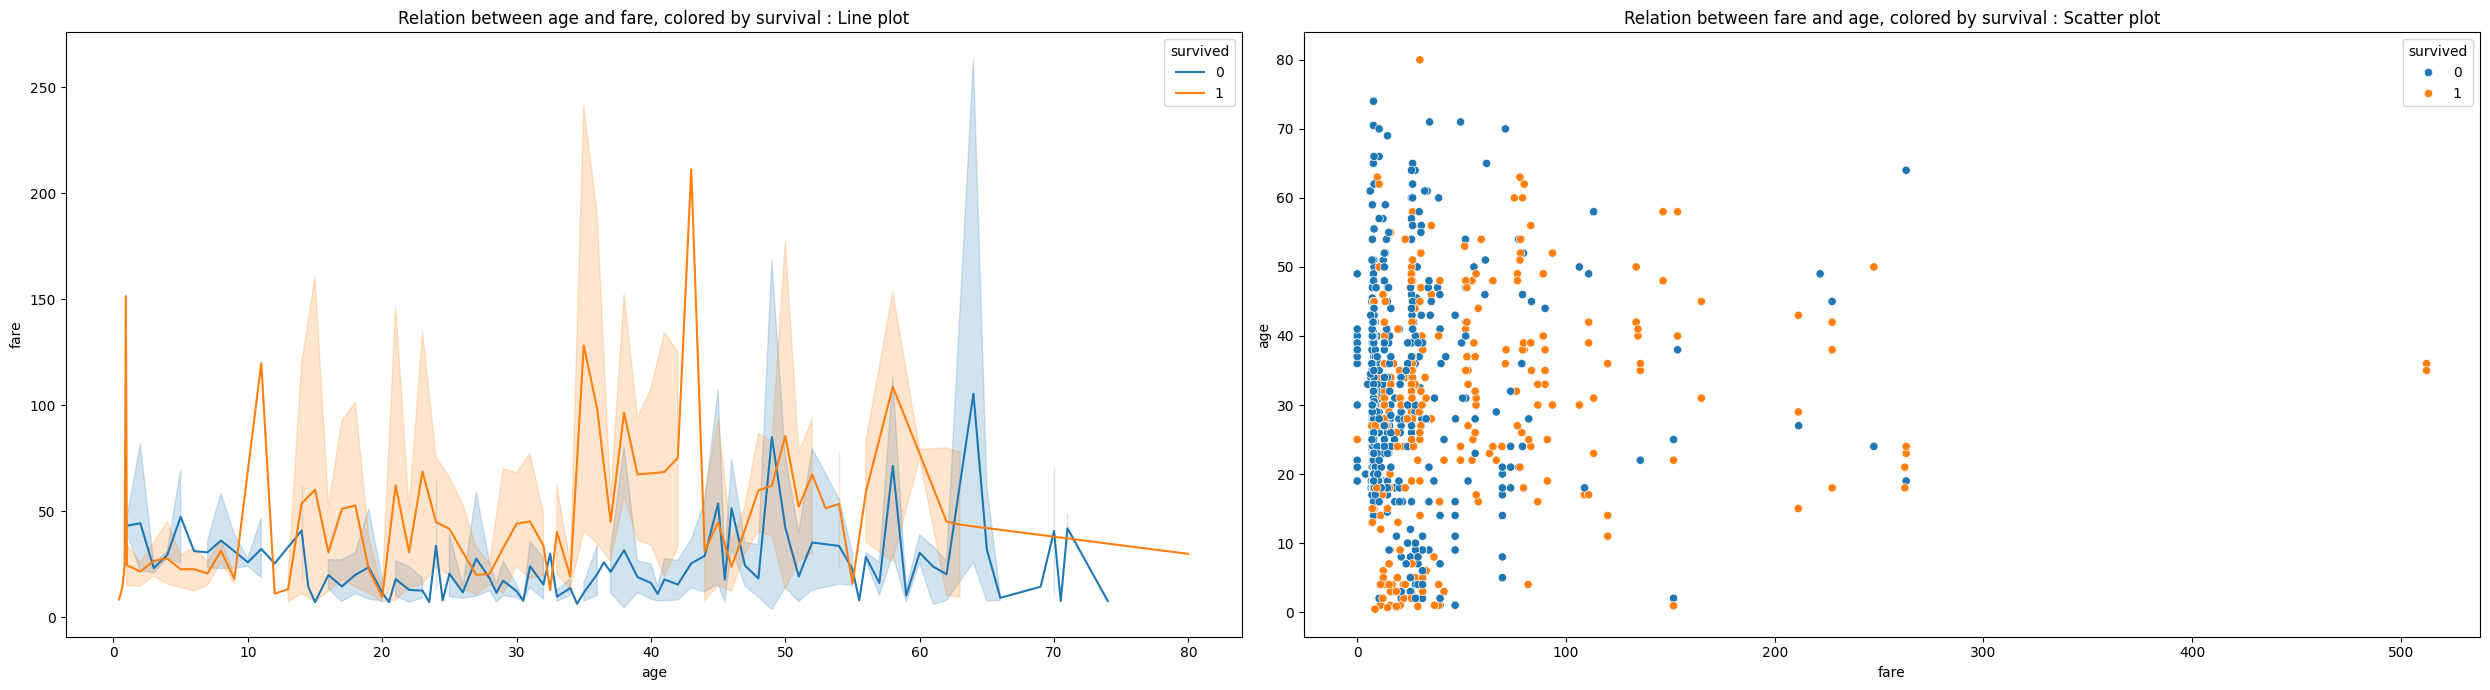

In [233]:
fig, axes = plt.subplots(1, 2, figsize=(25, 7))


sns.lineplot( x="age", y="fare", hue="survived", data=data, ax=axes[0])
axes[0].set_title("Relation between age and fare, colored by survival : Line plot")

# Relation between fare and age, colored by survival
sns.scatterplot(x="fare", y="age", hue="survived", data=data, ax=axes[1])
axes[1].set_title("Relation between fare and age, colored by survival : Scatter plot")
plt.tight_layout()
plt.show()

In [279]:
class_cols = ["1st_class", "2nd_class", "3rd_class"]

data["pclass"] = np.argmax(data[class_cols].values, axis=1) + 1


## Feature Engineering

## Relation Between Survived which is our target and other columns

#### Family Size and Survival Chances
- We can clearly see that, family size between 1 to 3, have higher chances of survivors compared to others, family size of 3 has higher rate of survival

/var/folders/_b/v2z7twxj4bbczz_fz9lgtb2r0000gx/T/ipykernel_27218/3888267685.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)


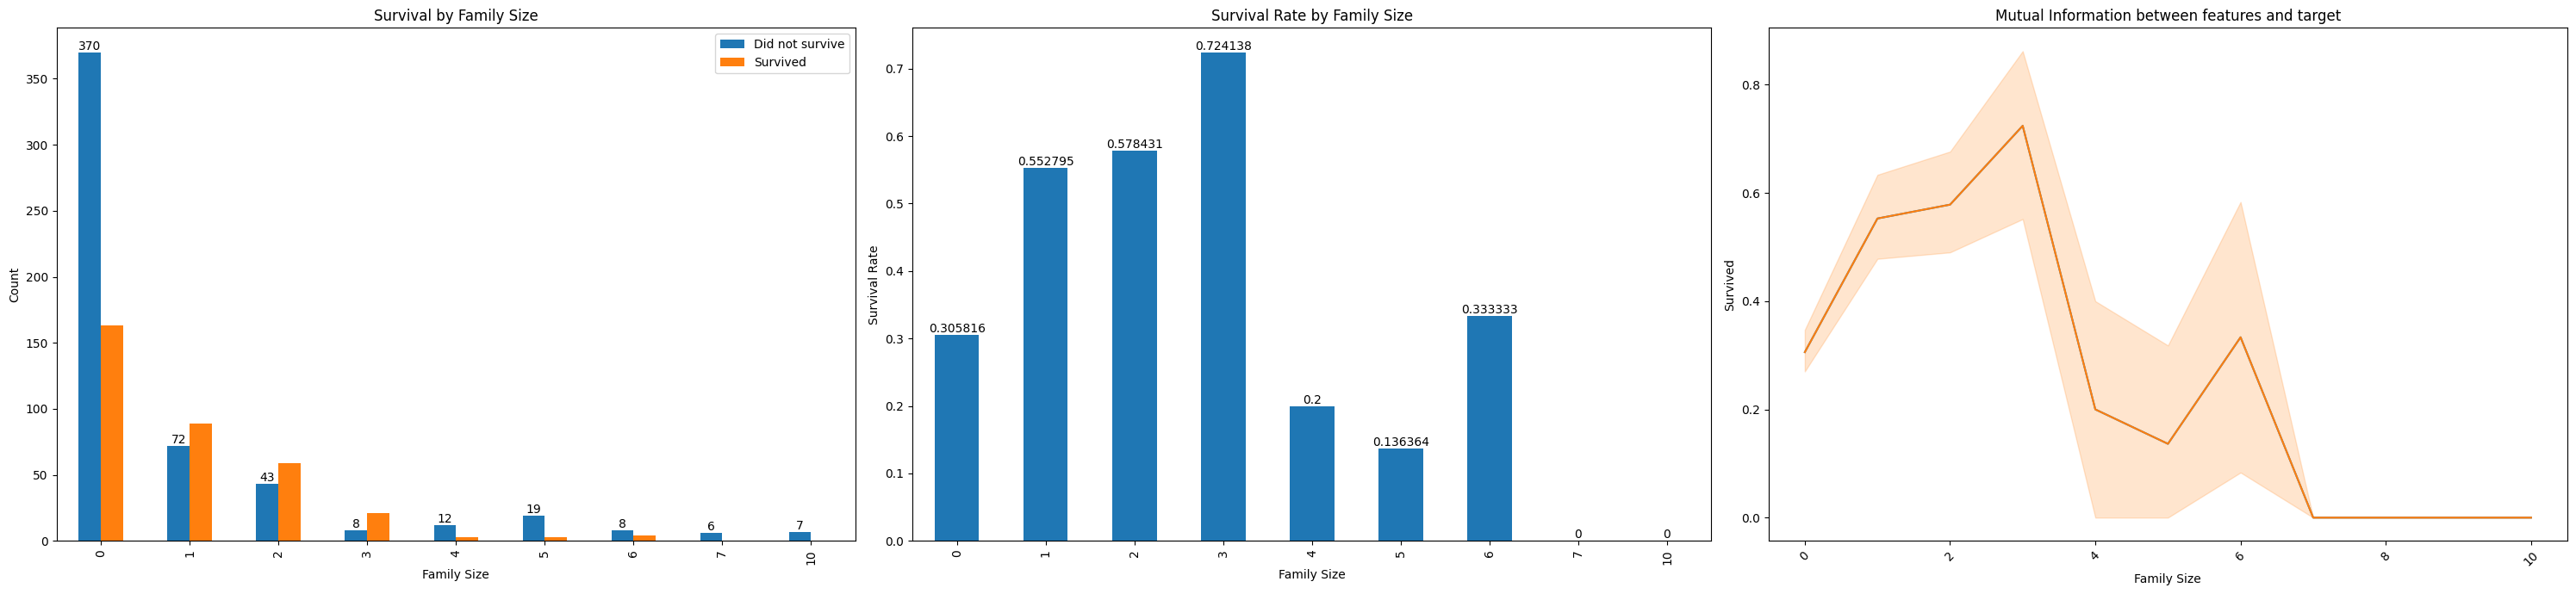

In [234]:
fig, axes = plt.subplots(1, 3, figsize=(30, 7))

grouped = data.groupby(["family_size", "survived"]).size().unstack()
grouped.plot(kind="bar", ax=axes[0])

axes[0].bar_label(axes[0].containers[0])
axes[0].set_title("Survival by Family Size")
axes[0].set_xlabel("Family Size")
axes[0].set_ylabel("Count")
axes[0].legend(["Did not survive", "Survived"])

rate = data.groupby(["family_size"])["survived"].mean()

rate.plot(kind="bar", ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
axes[1].set_title("Survival Rate by Family Size")
axes[1].set_ylabel("Survival Rate")
axes[1].set_xlabel("Family Size")


sns.lineplot(
    x=data.groupby("family_size")["survived"].mean().index,
    y=data.groupby("family_size")["survived"].mean().values,
    ax=axes[2]
)

sns.lineplot(y=data["survived"], x=data["family_size"], ax=axes[2]) 
axes[2].set_title("Mutual Information between features and target")
axes[2].set_xlabel("Family Size")
axes[2].set_ylabel("Survived")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

#### Age and Survival chances 
- Highest Surviuval Rate is of Age Group: 0-10 age group

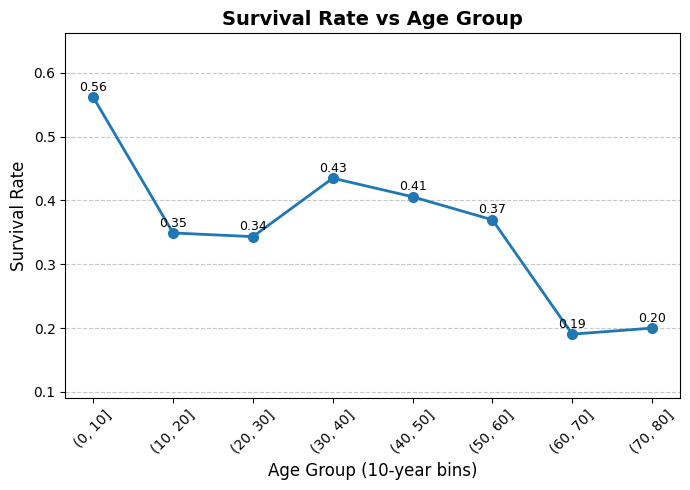

In [235]:
data["age_bin"] = pd.cut(
    data["age"],
    bins=range(0, 90, 10),   # 0-10, 10-20, ..., 80-90
)
age_survival = data.groupby("age_bin")["survived"].mean()

x = age_survival.index.astype(str)
y = age_survival.values

plt.figure(figsize=(7, 5))

plt.plot(x, y, marker='o', linewidth=2, markersize=7)

for xi, yi in zip(x, y):
    plt.text(xi, yi + 0.01, f"{yi:.2f}",
             ha='center', fontsize=9)

plt.title("Survival Rate vs Age Group", fontsize=14, fontweight='bold')
plt.xlabel("Age Group (10-year bins)", fontsize=12)
plt.ylabel("Survival Rate", fontsize=12)

plt.xticks(rotation=45)
plt.ylim(min(y)-0.1, max(y)+0.1)  # survival rate is always 0–1

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Gender and Survival Chances

- We can see there are higher rate of survival as Women

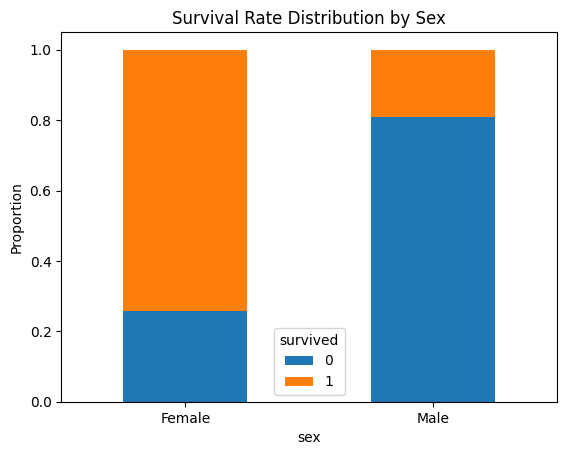

In [236]:
sex_counts = data.groupby(["sex", "survived"]).size().unstack()

sex_norm = sex_counts.div(sex_counts.sum(axis=1), axis=0)

sex_norm.plot(kind="bar", stacked=True)
plt.xticks([0, 1], ["Female", "Male"], rotation=0)
plt.title("Survival Rate Distribution by Sex")
plt.ylabel("Proportion")

plt.show()

#### Booking Class and Survival Rate
- We can also see that there are higher rate of survival if passenger was from 1st Class booking

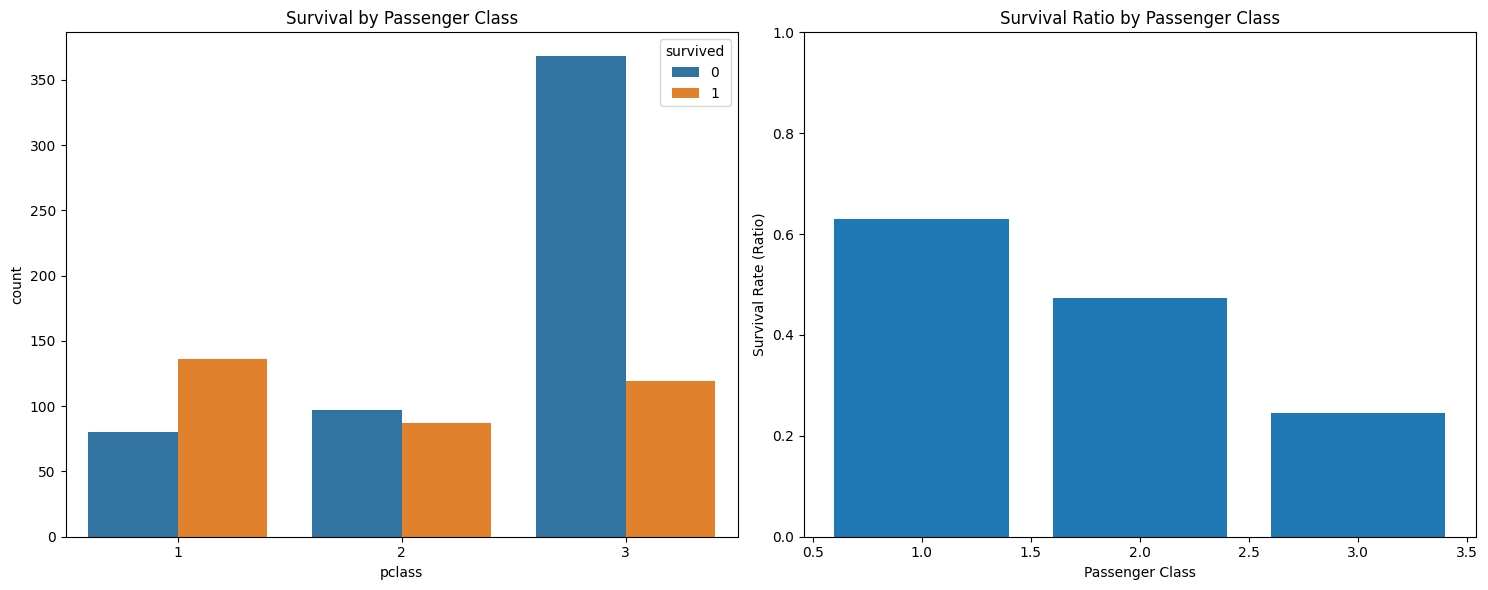

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.countplot(data=data, x="pclass", hue="survived", ax=axes[0])

axes[0].set_title("Survival by Passenger Class")


ratio = data.groupby("pclass")["survived"].mean()

axes[1].bar(ratio.index, ratio.values)
axes[1].set_title("Survival Ratio by Passenger Class")
axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Survival Rate (Ratio)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Fare and Survival Rate
- There are higher chances if your fare was higher, which also implies, the 1st class booking or higher class booking

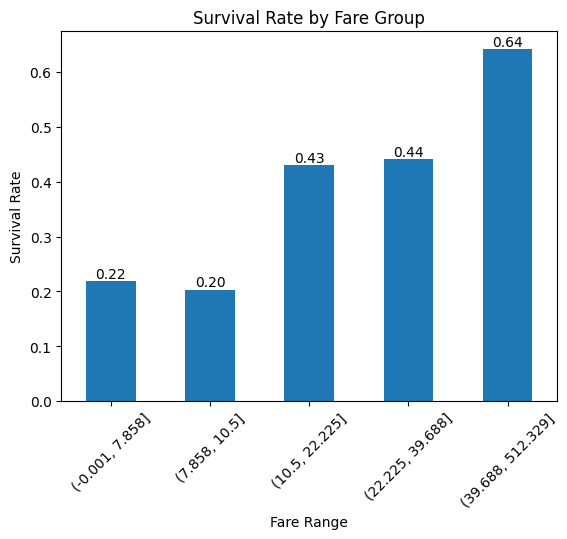

In [244]:
data["fare_bin"] = pd.qcut(data["fare"], 5)
fare_survival = data.groupby("fare_bin")["survived"].mean()

ax = fare_survival.plot(kind="bar")

ax.bar_label(ax.containers[0], fmt="%.2f")
plt.title("Survival Rate by Fare Group")
plt.xlabel("Fare Range")
plt.ylabel("Survival Rate")
plt.xticks(rotation=45)

plt.show()

### Finding Mututal Informationn Score

In [ ]:
data.columns

Index(['sex', 'age', 'family_size', 'fare', '1st_class', '2nd_class',
       '3rd_class', 'survived', 'age_bin', 'pclass', 'fare_bin'],
      dtype='str')

In [ ]:
from sklearn.feature_selection import mutual_info_regression

cols = ['sex', 'age', 'family_size', 'fare', 'survived', 'age_bin', 'pclass', 'fare_bin']
X = data[cols].copy()
y = X.pop("survived")

# Label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

# All discrete features should now have integer dtypes (double-check this before using MI!)
discrete_features = X.select_dtypes(include=["int"])
discrete_cols = discrete_features.dtypes == int

In [ ]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(discrete_features, y, discrete_cols)
mi_scores  # show a few features with their MI scores

sex            0.153227
pclass         0.066854
family_size    0.061903
Name: MI Scores, dtype: float64

Text(0.5, 1.0, 'Mutual Information Scores')

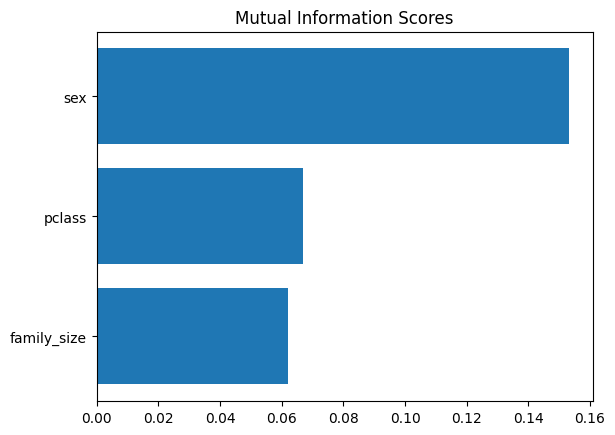

In [ ]:
scores = mi_scores
scores = scores.sort_values(ascending=True)
width = np.arange(len(scores))
ticks = list(scores.index)
plt.barh(width, scores)
plt.yticks(width, ticks)
plt.title("Mutual Information Scores")